In [1]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

c:\ProgramData\anaconda3\envs\wildfire_gnn\python.exe
1.26.4


In [2]:
sys.path.append("../src")

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.data.loader import WildfireDatasetManager
from wildfire_gnn.data.preprocessing import read_single_band_raster, raster_to_flat_table
from wildfire_gnn.evaluation.visualization import plot_raster, plot_histogram

c:\ProgramData\anaconda3\envs\wildfire_gnn\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
import os
os.chdir("..")

config = load_yaml_config("configs/data_config.yaml")
manager = WildfireDatasetManager(config)
manager.validate_structure()

2026-03-27 17:19:08 | INFO | wildfire_gnn.data.loader | Dataset structure validation passed.


In [5]:
target_path = manager.paths.raw_files_dir / "Burn_Prob.img"
target_array, target_meta = read_single_band_raster(target_path)

target_array.shape

(7597, 7555)

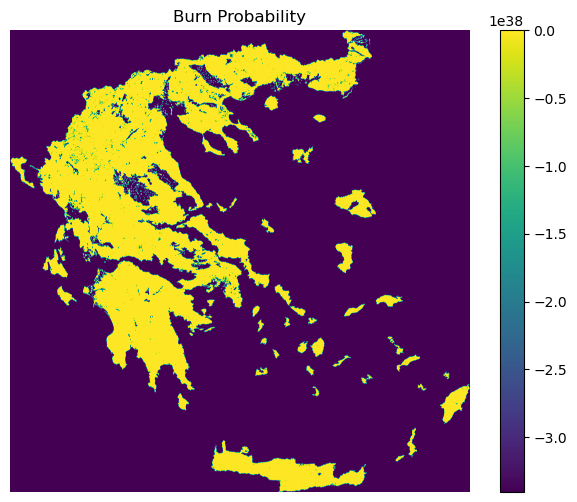

In [6]:
plot_raster(target_array, title="Burn Probability")

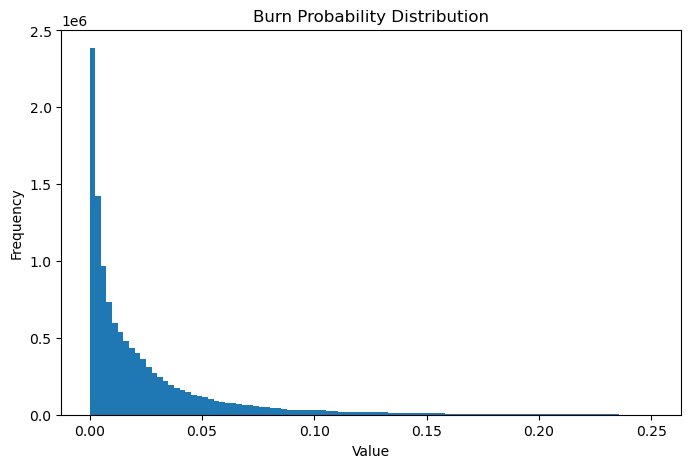

In [7]:
flat = raster_to_flat_table(
    target_array,
    transform=target_meta["transform"],
    nodata=target_meta["nodata"]
)

plot_histogram(flat["value"], title="Burn Probability Distribution")

In [8]:
features = config["layers"]["rasters"]

feature_data = {}

for name in features:
    path = manager.paths.raw_files_dir / name
    arr, meta = read_single_band_raster(path)
    feature_data[name] = (arr, meta)

Burn_Prob.img (7597, 7555)


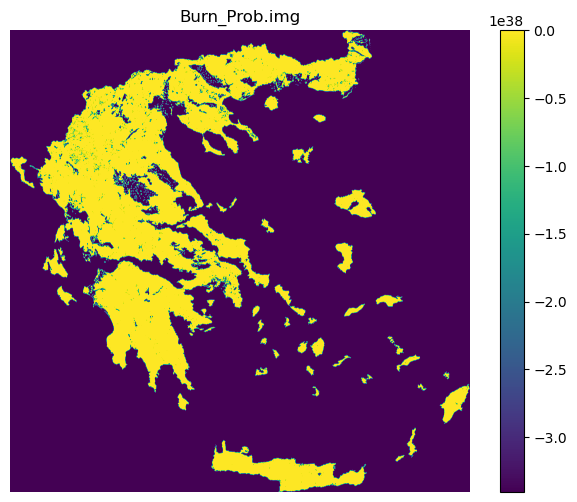

CFL.img (7597, 7555)


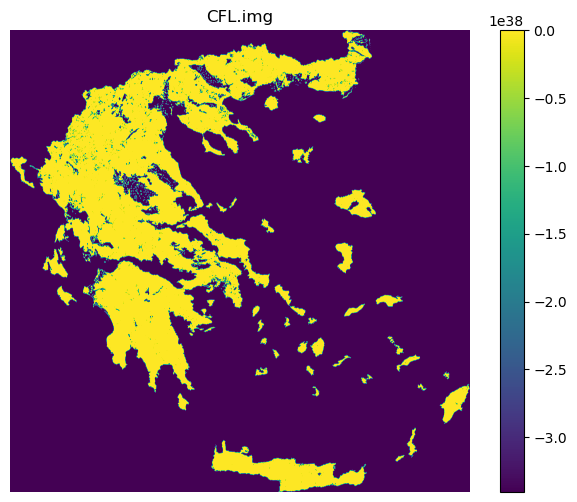

FSP_Index.img (7592, 7541)


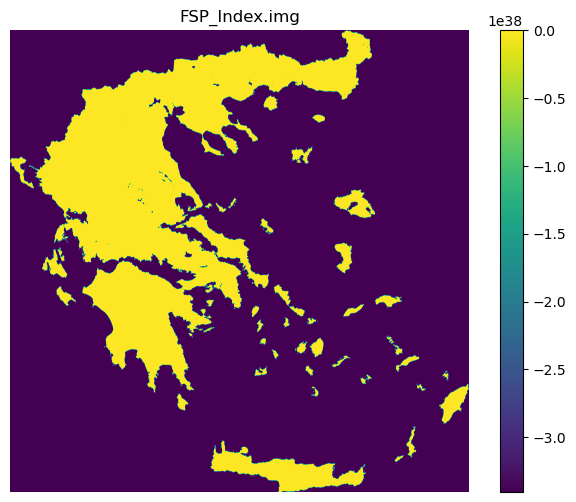

Fuel_Models.img (7932, 9039)


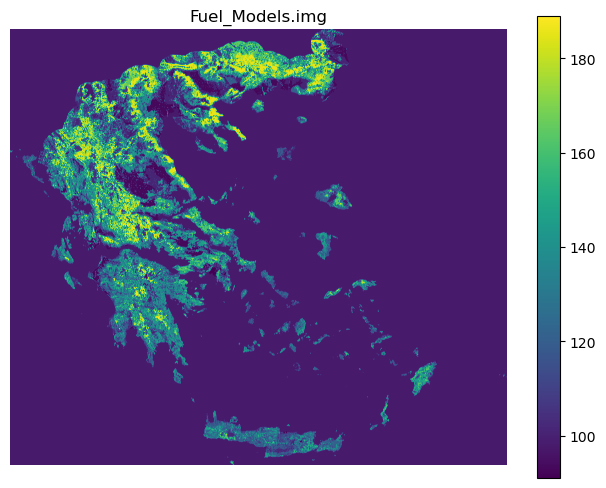

Ignition_Prob.img (7733, 9039)


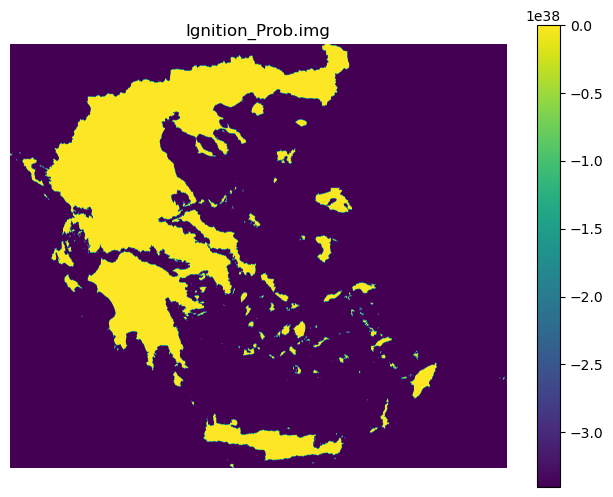

Struct_Exp_Index.img (7592, 7541)


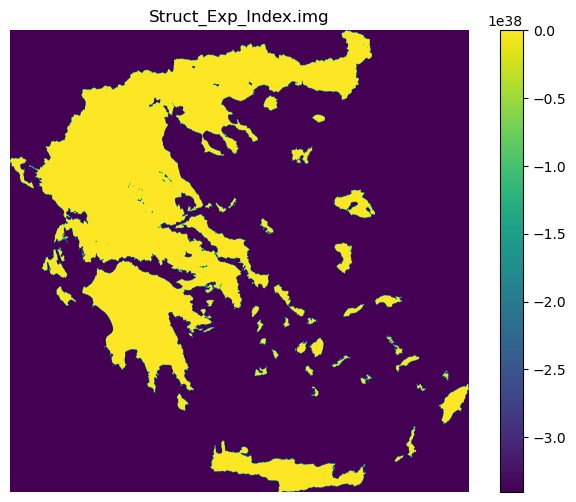

In [9]:
for name, (arr, meta) in feature_data.items():
    print(name, arr.shape)
    plot_raster(arr, title=name)

In [10]:
for name, (arr, _) in feature_data.items():
    print(name, arr.shape)

Burn_Prob.img (7597, 7555)
CFL.img (7597, 7555)
FSP_Index.img (7592, 7541)
Fuel_Models.img (7932, 9039)
Ignition_Prob.img (7733, 9039)
Struct_Exp_Index.img (7592, 7541)


## Dataset Exploration Summary

### Objective of this exploration
The goal of this first exploration phase was to inspect the wildfire simulation dataset structurally and visually before moving to graph construction and modeling. At this stage, the purpose was not to train a model yet, but to answer a few critical research questions:

1. What should be used as the prediction target?
2. Which rasters can serve as candidate input features?
3. Are the data layers spatially aligned?
4. What data quality issues exist, such as nodata regions or inconsistent raster shapes?
5. Is the dataset suitable for graph-based wildfire modeling?

This exploration is a foundational step because the quality of the graph construction stage depends entirely on understanding the raster geometry, variable semantics, and spatial consistency of the data.

---

## 1. Loaded target variable

The primary target selected for the project is:

- **`Burn_Prob.img`**

This raster represents burn probability over the landscape and is the most suitable initial prediction target for the wildfire spread modeling task.

### Why `Burn_Prob.img` is an appropriate target
From the dataset audit and visualization results, this layer appears to encode a probabilistic wildfire outcome over the study area rather than a simple binary burned/unburned label. This makes it especially valuable for the project because:

- it naturally fits the problem of predicting wildfire spread risk,
- it is directly tied to the stochastic simulation outputs described in the project concept,
- it supports uncertainty-aware modeling,
- it is suitable for both regression-style prediction and later calibration analysis.

### Statistical findings for `Burn_Prob.img`
From the preprocessing audit:

- **Shape:** `(7597, 7555)`
- **Data type:** `float32`
- **CRS:** `EPSG:2100`
- **NoData:** `-3.402823e+38`
- **Minimum valid value:** `3.642630645117606e-06`
- **Maximum valid value:** `0.2508818507194519`
- **Mean:** `0.024166792480198023`
- **Standard deviation:** `0.0328344341023829`
- **Median:** `0.012004395015537739`
- **Valid pixel count:** `11,966,420`

### Interpretation
These statistics show that burn probability values are concentrated near zero, with a long right tail. This was also confirmed visually in the histogram. Most spatial cells have relatively low burn probability, while a smaller subset of cells carries substantially higher risk.

This is an important finding because it means the target distribution is **highly skewed**, not uniform. That will matter later for:

- loss function design,
- evaluation metrics,
- calibration behavior,
- uncertainty interpretation.

---

## 2. Distribution of the target

The histogram of `Burn_Prob.img` showed that the target is strongly right-skewed.

### Key distributional observation
Most of the values are clustered near zero, and only a minority of cells have moderate or high burn probability values.

### Why this matters
This means the prediction problem is not balanced in the usual sense. A naive model could perform reasonably on average simply by predicting low values everywhere, while still missing the most important high-risk areas.

This has several implications for later stages:

- model evaluation should not rely only on average error,
- calibration is especially important because decision-making depends on trustworthy probabilities,
- uncertainty estimation will be important in low-frequency but high-risk regions,
- later experiments may need additional analysis of tail behavior or high-risk thresholds.

---

## 3. Explored candidate input rasters

The following raster layers were inspected as candidate node features:

- `Burn_Prob.img`
- `CFL.img`
- `FSP_Index.img`
- `Fuel_Models.img`
- `Ignition_Prob.img`
- `Struct_Exp_Index.img`

Below is a summary of the findings for each.

---

### 3.1 `CFL.img`

- **Shape:** `(7597, 7555)`
- **Data type:** `float32`
- **CRS:** `EPSG:2100`
- **NoData:** `-3.402823e+38`
- **Minimum valid value:** `1.0`
- **Maximum valid value:** `25.0`
- **Mean:** `3.8168272372417316`
- **Standard deviation:** `3.4511725254862133`
- **Median:** `2.5226070880889893`
- **Valid pixel count:** `11,965,691`

### Interpretation
This raster has the same shape as `Burn_Prob.img`, which is a positive sign for alignment with the target. Visually, it covers the same landmass footprint and likely encodes a continuous wildfire-related landscape factor. Because of its spatial similarity and compatible geometry, it is a strong candidate feature.

---

### 3.2 `FSP_Index.img`

- **Shape:** `(7592, 7541)`
- **Data type:** `float32`
- **CRS:** `EPSG:2100`
- **NoData:** `-3.402823e+38`
- **Minimum valid value:** `1.0`
- **Maximum valid value:** `38119.5546875`
- **Mean:** `1030.7122727860053`
- **Standard deviation:** `1544.6664248312634`
- **Median:** `453.0200500488281`
- **Valid pixel count:** `13,067,375`

### Interpretation
This layer has a different shape from the target, which immediately reveals a spatial alignment issue. Its values have a very large range, suggesting that this feature may require normalization or scaling before it is used in a model. Because the raster footprint is similar but not identical, this layer will need resampling to a common reference grid before graph construction.

---

### 3.3 `Fuel_Models.img`

- **Shape:** `(7932, 9039)`
- **Data type:** `uint8`
- **CRS:** `EPSG:2100`
- **NoData:** `255.0`
- **Minimum valid value:** `91.0`
- **Maximum valid value:** `189.0`
- **Mean:** `105.41674799463992`
- **Standard deviation:** `20.240109416069995`
- **Median:** `98.0`
- **Valid pixel count:** `71,697,348`

### Interpretation
This raster differs substantially from the others in both shape and value type. It appears to be a **categorical layer**, not a continuous one, because it is stored as `uint8` and takes on discrete values over a bounded numeric range.

This is an important finding. In the future graph pipeline, this raster should not be treated exactly like a continuous feature. More likely, it should be:

- encoded categorically,
- mapped into categories or embeddings,
- or handled separately from normalized continuous variables.

It is still a very important candidate feature because fuel type is highly relevant to wildfire behavior.

---

### 3.4 `Ignition_Prob.img`

- **Shape:** `(7733, 9039)`
- **Data type:** `float32`
- **CRS:** `EPSG:2100`
- **NoData:** `-3.402823e+38`
- **Minimum valid value:** `0.0`
- **Maximum valid value:** `0.9999600052833557`
- **Mean:** `0.2678315180143401`
- **Standard deviation:** `0.23503777396966882`
- **Median:** `0.20024000108242035`
- **Valid pixel count:** `13,076,068`

### Interpretation
This layer likely encodes ignition likelihood or ignition-related risk. It is conceptually very important because ignition probability is closely tied to wildfire initiation risk. However, its geometry differs substantially from the target raster, so it will need alignment before use.

This feature will probably become one of the strongest input variables in the graph model.

---

### 3.5 `Struct_Exp_Index.img`

- **Shape:** `(7592, 7541)`
- **Data type:** `float32`
- **CRS:** `EPSG:2100`
- **NoData:** `-3.402823e+38`
- **Minimum valid value:** `0.0`
- **Maximum valid value:** `10527.2841796875`
- **Mean:** `225.64585836429345`
- **Standard deviation:** `314.416683600147`
- **Median:** `115.84769439697266`
- **Valid pixel count:** `13,067,375`

### Interpretation
This raster also differs from the target in shape. Its value range is wide, and it likely describes some form of structural exposure or landscape vulnerability. Like `FSP_Index.img`, it will need normalization and resampling before being integrated into a graph feature matrix.

---

## 4. Visual findings from raster plots

The raster plots revealed several important visual patterns.

### 4.1 Shared study region footprint
All major layers broadly correspond to the geography of Greece. The general landmass and islands are visible in each layer, confirming that the dataset is spatially coherent at the country scale.

### 4.2 Large nodata background
A substantial portion of the raster extent is background or nodata. This is expected because the raster bounding boxes include areas outside valid land or outside the meaningful study mask.

This matters because later graph construction should only use **valid cells** and must avoid generating graph nodes for nodata/background regions.

### 4.3 Internal spatial variation
The target and feature rasters clearly contain meaningful spatial patterns over mainland Greece and the islands. This is encouraging because it suggests the model will have access to geographically structured variation rather than only random noise.

### 4.4 Some earlier plots were visually dominated by nodata
In raw raster display, nodata values distorted the color scale and visually compressed valid values. However, this issue was already identified and handled numerically during preprocessing. For subsequent plotting stages, masked visualization will be more informative.

---

## 5. Critical engineering finding: rasters are not aligned

One of the most important outcomes of this exploration is that the rasters do **not** all share the same shape.

### Observed raster shapes
- `Burn_Prob.img` → `(7597, 7555)`
- `CFL.img` → `(7597, 7555)`
- `FSP_Index.img` → `(7592, 7541)`
- `Fuel_Models.img` → `(7932, 9039)`
- `Ignition_Prob.img` → `(7733, 9039)`
- `Struct_Exp_Index.img` → `(7592, 7541)`

### Why this is critical
This means the feature rasters cannot simply be stacked directly into a feature tensor or node matrix. Before graph construction, all input layers must be transformed onto a **common reference grid**.

Without that step:

- cell-to-cell correspondence would be invalid,
- graph nodes would not represent the same physical locations across layers,
- feature vectors would be spatially inconsistent,
- model outputs would be scientifically unreliable.

### Research and engineering implication
This is the first major geospatial preprocessing problem in the project and one of the most important technical steps before modeling. The next phase must therefore include a professional raster alignment strategy.

---

## 6. Confirmed vector and geodatabase layers

The dataset audit confirmed three vector layers are available both as shapefiles and in the geodatabase:

- `Fire_Ignitions`
- `Fire_Perimeters`
- `Pyromes`

### Why these layers matter
These vector layers are very useful for future research and analysis:

#### `Fire_Ignitions`
This may provide point-level ignition information, which could later help:
- interpret ignition risk,
- validate ignition-related spatial patterns,
- or enrich intervention-aware modeling.

#### `Fire_Perimeters`
This may encode historical or simulated fire boundaries. It could later be useful for:
- visualization,
- spatial validation,
- or overlay analysis.

#### `Pyromes`
This is especially important because pyromes are ecologically meaningful spatial units. They may later support:
- regional stratification,
- domain shift analysis,
- grouped evaluation,
- or more interpretable graph partitioning.

These layers are not yet used in the first graph prototype, but they are strategically valuable for later experiments and paper quality.

---

## 7. Data quality observations

### 7.1 CRS consistency
All inspected rasters use:

- **`EPSG:2100`**

This is a strong positive finding because it means there is no immediate coordinate reference mismatch between layers.

### 7.2 Nodata handling
Continuous rasters use a large negative sentinel nodata value:

- **`-3.402823e+38`**

The categorical `Fuel_Models.img` uses:

- **`255.0`**

These values were correctly filtered in the preprocessing audit. This is essential because otherwise summary statistics and visualizations would be corrupted.

### 7.3 Feature-type heterogeneity
The dataset contains both:

- continuous rasters,
- and categorical rasters.

This means the future graph feature engineering stage must distinguish between variable types rather than treating every raster identically.

### 7.4 Scale heterogeneity
Feature ranges vary substantially across rasters. For example:
- probability-like layers are bounded near `[0, 1]`,
- some exposure/index layers have very large positive ranges,
- `Fuel_Models.img` is categorical.

This means later preprocessing must include careful feature scaling and possibly separate treatment for categorical inputs.

---

## 8. Main findings of the exploration

This exploration produced several important conclusions:

### Finding 1
**`Burn_Prob.img` is a valid and meaningful primary target** for the wildfire modeling task.

### Finding 2
The dataset includes several strong candidate feature layers:
- `CFL.img`
- `FSP_Index.img`
- `Fuel_Models.img`
- `Ignition_Prob.img`
- `Struct_Exp_Index.img`

### Finding 3
The target distribution is strongly skewed toward low burn probability values, which will affect modeling and evaluation design.

### Finding 4
The rasters are **not spatially aligned**, which is the most important preprocessing issue before graph construction.

### Finding 5
At least one feature layer (`Fuel_Models.img`) is categorical and should be handled differently from continuous layers.

### Finding 6
The vector layers (`Fire_Ignitions`, `Fire_Perimeters`, `Pyromes`) provide useful spatial context and may support future analysis, validation, and intervention-aware modeling.

### Finding 7
The dataset is suitable for graph-based wildfire modeling, but only after rigorous preprocessing and alignment.

---

## 9. Implications for the next phase

Based on this exploration, the next stage of the project should focus on the following tasks:

1. **Choose a reference raster grid**  
   A single raster must be selected as the spatial reference for all subsequent alignment.

2. **Resample and align all feature rasters**  
   Every feature must be projected onto the same grid so that each node corresponds to the same geographic cell across all layers.

3. **Define node construction rules**  
   Each valid raster cell on the reference grid will likely become a node in the graph.

4. **Define the node feature vector**  
   Node features will likely include:
   - CFL
   - FSP Index
   - Fuel Model
   - Ignition Probability
   - Structural Exposure Index
   - optional coordinates or spatial indicators

5. **Handle categorical vs. continuous features properly**  
   `Fuel_Models.img` should be treated differently from continuous layers.

6. **Build a valid-cell mask**  
   Graph nodes should only be created for cells with valid aligned data.

7. **Prepare for graph edge construction**  
   Once the common grid is defined, spatial adjacency can be created using 4-neighbor or 8-neighbor connectivity.

---

## 10. Conclusion of this exploration phase

This initial exploration successfully established that the dataset is rich, spatially meaningful, and well suited for a wildfire prediction project that combines geospatial machine learning, uncertainty modeling, and graph neural networks.

At the same time, it revealed the first major technical challenge: **the feature rasters are not already aligned to a common grid**. This is not a problem with the dataset itself, but it is a critical preprocessing requirement for any scientifically valid graph-based model.

Therefore, the exploration phase achieved its purpose. We now have:

- a justified primary target,
- a set of candidate features,
- evidence of spatial structure,
- awareness of nodata and variable-type issues,
- and a clear next step: **raster alignment and graph-ready node definition**.

This provides a strong and professional foundation for the next stage of the project.